Type: <class 'torch.Tensor'>
Shape: torch.Size([104091, 301])
Dtype: torch.int64
First 5 sequences:
tensor([[50258,  4455, 21185,  ...,   402,   290, 23842],
        [50258, 11232, 25332,  ...,    11,   262,  5531],
        [50258,  2080,   262,  ...,   247,   198,   198],
        [50258, 11753,   262,  ...,  1770,  7080,  4533],
        [50258, 11177,  1921,  ...,   332,    25,   720]])

First sequence:
tensor([50258,  4455, 21185,   198,   198, 17354,   198,   198,  2202,   465,
         5011,   338,  2801,    12,    69,   515,  4130,  2739,   938,   614,
           11,   674,  4139,   329,  9765,  3903,    11, 14620,   290,   262,
        10231, 18493,  6241,   465,  4601,   326,   262,  6638,  5070,   815,
         7719,   366,    64,  3026,   290,  6563,  3592,  2691,   526,   198,
          198,   464,  4139,    11,  8962,  7970,  1482,  3287,    11,  5220,
          326, 24933,  2421,   366,  1040, 10514,     1,   284,  1064,   262,
         2691,  6628,  3306,   284, 12991,   7

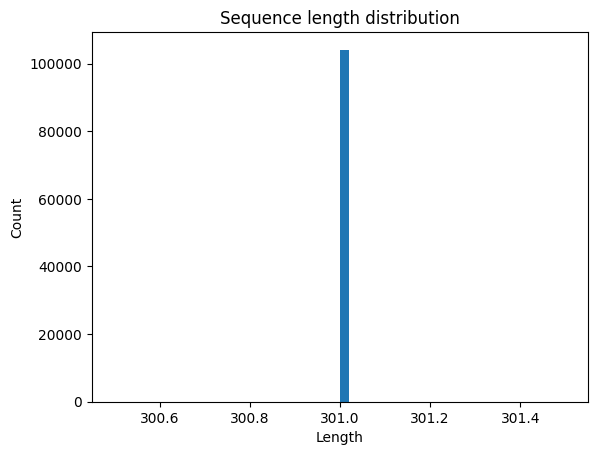

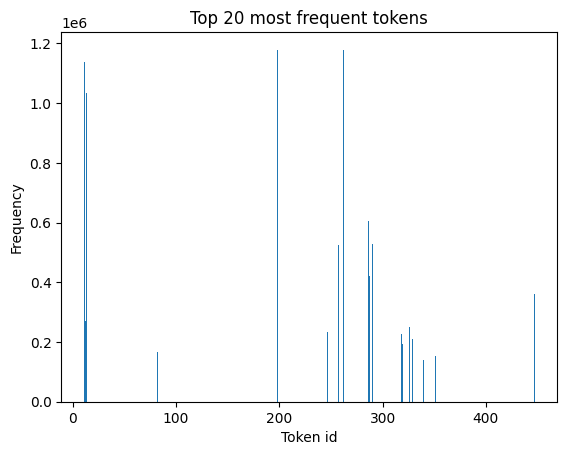


Sequence 0:
[50258, 4455, 21185, 198, 198, 17354, 198, 198, 2202, 465, 5011, 338, 2801, 12, 69, 515, 4130, 2739, 938, 614, 11, 674, 4139, 329, 9765, 3903, 11, 14620, 290, 262, 10231, 18493, 6241, 465, 4601, 326, 262, 6638, 5070, 815, 7719, 366, 64, 3026, 290, 6563, 3592, 2691, 526, 198, 198, 464, 4139, 11, 8962, 7970, 1482, 3287, 11, 5220, 326, 24933, 2421, 366, 1040, 10514, 1, 284, 1064, 262, 2691, 6628, 3306, 284, 12991, 786, 674, 10270, 287, 262, 4875, 3773, 11, 290, 4752, 326, 262, 42674, 338, 366, 20418, 527, 11233, 5224, 553, 351, 663, 8381, 4455, 21185, 7142, 11, 373, 257, 3306, 636, 286, 326, 12141, 13, 198, 198, 464, 4139, 1244, 307, 6655, 284, 7073, 326, 257, 1049, 867, 286, 465, 7812, 395, 9188, 1104, 465, 6227, 329, 24933, 284, 307, 366, 37636, 290, 6563, 1, 2691, 13, 679, 1244, 307, 772, 517, 6655, 284, 760, 326, 3026, 6628, 4433, 262, 38968, 286, 465, 21185, 11628, 11, 780, 21185, 286, 262, 1611, 339, 318, 24950, 10630, 1931, 4147, 6628, 290, 36317, 879, 13, 198, 198, 11

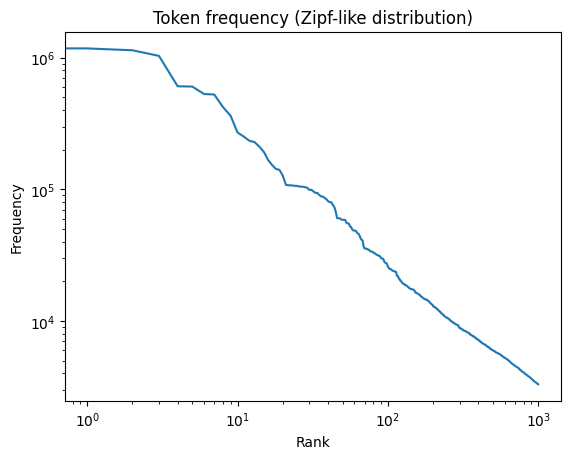

===== DATASET SUMMARY =====
Sequences: 104091
Sequence shape: torch.Size([104091, 301])
Token range: (0, 50258)
Unique tokens: 49696
Avg sequence length: 301.0


In [6]:
import torch
import huggingface_hub
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

validation_fname = huggingface_hub.hf_hub_download(
    repo_id="ArthurConmy/redwood_attn_2l",
    filename="validation_data.pt"
)

data = torch.load(validation_fname, map_location="cpu").long()

print("Type:", type(data))
print("Shape:", data.shape)
print("Dtype:", data.dtype)

print("First 5 sequences:")
print(data[:5])

print("\nFirst sequence:")
print(data[0])

print("Min token id:", data.min().item())
print("Max token id:", data.max().item())

print("Mean token id:", data.float().mean().item())
print("Std token id:", data.float().std().item())

seq_lengths = [len(seq) for seq in data]

print("Num sequences:", len(seq_lengths))
print("Min length:", min(seq_lengths))
print("Max length:", max(seq_lengths))
print("Mean length:", np.mean(seq_lengths))

plt.hist(seq_lengths, bins=50)
plt.title("Sequence length distribution")
plt.xlabel("Length")
plt.ylabel("Count")
plt.show()

flat = data.flatten().tolist()
counter = Counter(flat)

most_common = counter.most_common(20)
tokens, counts = zip(*most_common)

plt.bar(tokens, counts)
plt.title("Top 20 most frequent tokens")
plt.xlabel("Token id")
plt.ylabel("Frequency")
plt.show()

for i in range(3):
    print(f"\nSequence {i}:")
    print(data[i].tolist())


unique_tokens = len(counter)
print("Unique tokens:", unique_tokens)

zero_ratio = (data == 0).float().mean().item()
print("Ratio of token 0:", zero_ratio)


def show_windows(seq, window=10):
    seq = seq.tolist()
    for i in range(0, len(seq) - window, window):
        print(seq[i:i+window])

print("Example sliding windows:")
show_windows(data[0], window=10)


def get_batch(data, batch_size=8):
    idx = torch.randint(0, len(data), (batch_size,))
    return data[idx]

batch = get_batch(data)
print(batch.shape)
print(batch)

ranks = np.arange(len(counter))
freqs = np.array(sorted(counter.values(), reverse=True))

plt.loglog(ranks[:1000], freqs[:1000])
plt.title("Token frequency (Zipf-like distribution)")
plt.xlabel("Rank")
plt.ylabel("Frequency")
plt.show()

print("===== DATASET SUMMARY =====")
print("Sequences:", len(data))
print("Sequence shape:", data.shape)
print("Token range:", (data.min().item(), data.max().item()))
print("Unique tokens:", unique_tokens)
print("Avg sequence length:", np.mean(seq_lengths))




In [5]:
import os
import torch
import transformers
import huggingface_hub

# Patch tokenizer loading

os.environ["TRANSFORMERS_USE_FAST"] = "True"

orig_auto = transformers.AutoTokenizer.from_pretrained
orig_gpt2 = transformers.GPT2Tokenizer.from_pretrained
orig_gpt2_fast = transformers.GPT2TokenizerFast.from_pretrained

def universal_tokenizer_patch(orig_fn):
    def patched_fn(pretrained_model_name_or_path, *args, **kwargs):
        if (
            isinstance(pretrained_model_name_or_path, str)
            and "redwood" in pretrained_model_name_or_path.lower()
        ):
            pretrained_model_name_or_path = "gpt2"

        kwargs["use_fast"] = True
        return orig_fn(pretrained_model_name_or_path, *args, **kwargs)

    return patched_fn

transformers.AutoTokenizer.from_pretrained = universal_tokenizer_patch(orig_auto)
transformers.GPT2Tokenizer.from_pretrained = universal_tokenizer_patch(orig_gpt2)
transformers.GPT2TokenizerFast.from_pretrained = universal_tokenizer_patch(orig_gpt2_fast)

# Load data

validation_fname = huggingface_hub.hf_hub_download(
    repo_id="ArthurConmy/redwood_attn_2l",
    filename="validation_data.pt"
)

data = torch.load(validation_fname, map_location="cpu").long()

# Load tokenizer

tokenizer = transformers.AutoTokenizer.from_pretrained(
    "ArthurConmy/redwood_tokenizer"
)

# Decode examples

for i in range(10):
    print(f"\n{'='*80}")
    print(f"SEQUENCE {i}")
    print(f"{'='*80}")

    text = tokenizer.decode(
        data[i].tolist(),
        skip_special_tokens=False
    )

    print(text)


ids = data[0][:100].tolist()

for tok_id in ids:
    token = tokenizer.convert_ids_to_tokens(tok_id)
    print(f"{tok_id:5d} -> {repr(token)}")


SEQUENCE 0
 Internet censorship

Updated

On his department's ill-fated blog late last year, our Minister for Broadband, Communications and the Digital Economy expressed his wish that the Australian Government should promote "a civil and confident society online."

The Minister, Senator Stephen Conroy, suggested that Australians require "inspiration" to find the online confidence necessary to maximise our participation in the digital economy, and claimed that the ALP's "Cyber Safety Plan," with its controversial Internet censorship regime, was a necessary part of that inspiration.

The Minister might be surprised to discover that a great many of his loudest critics support his desire for Australians to be "civil and confident" online. He might be even more surprised to know that civil confidence requires the abandonment of his censorship proposals, because censorship of the kind he is advocating actively erodes confidence and civility.

David Marr recently observed that while Australi